In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', palette='muted')

# Load Dataset
df = sns.load_dataset('tips')

print('Shape Dataset:', df.shape)
print('\nTipe Kolom:')
print(df.dtypes)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))
print('\nMissing Values:')
print(df.isnull().sum())
print('\nJumlah data per Hari:')
print(df['day'].value_counts())
print('\nJumlah data per Waktu Makan:')
print(df['time'].value_counts())

Shape Dataset: (244, 7)

Tipe Kolom:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Statistik Deskriptif:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

Missing Values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Jumlah data per Hari:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Jumlah data per Waktu Makan:
time
Dinner    176
Lunch      68
Name: count, dtype: int64


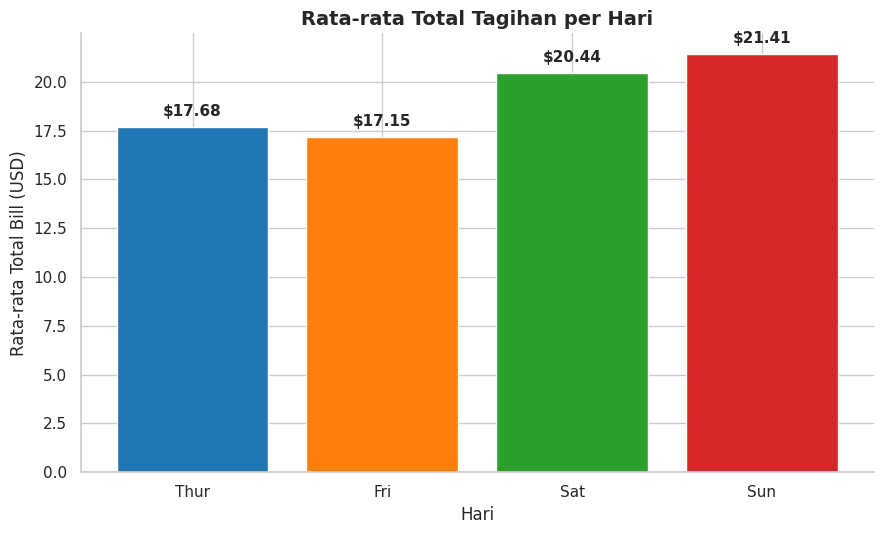

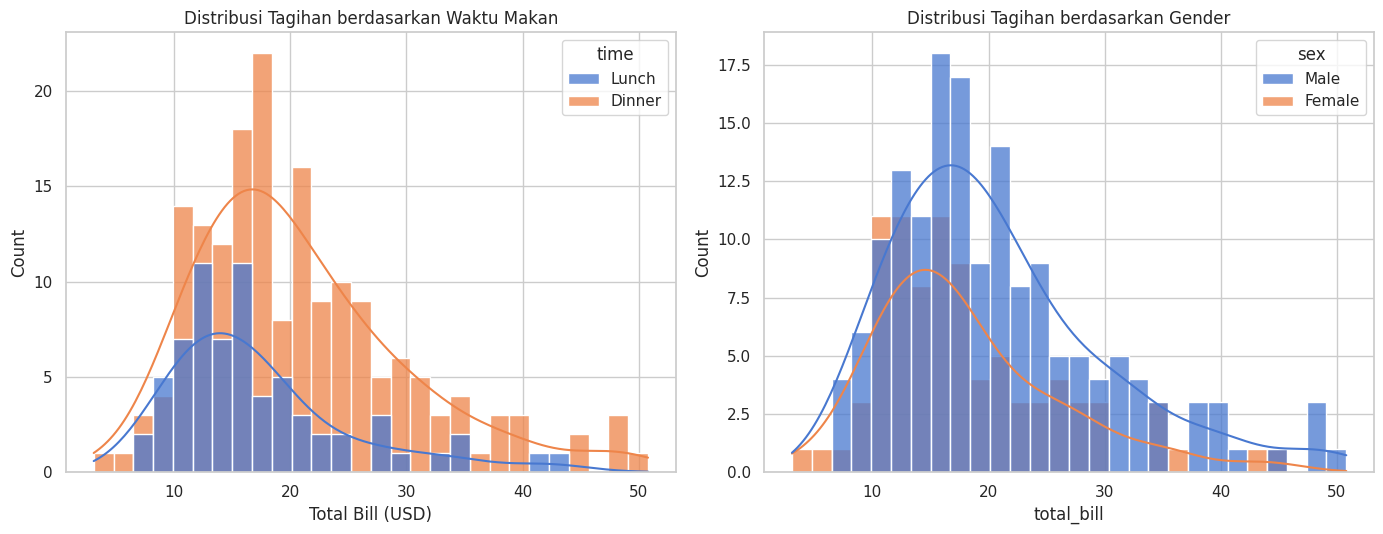

In [2]:
urutan_hari = ['Thur', 'Fri', 'Sat', 'Sun']

# Grafik 1: Bar Chart
fig, ax = plt.subplots(figsize=(9, 5.5))
avg_bill = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)
bars = ax.bar(avg_bill.index, avg_bill.values,
              color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='white')
ax.bar_label(bars, fmt='$%.2f', padding=6, fontsize=11, fontweight='bold')
ax.set_title('Rata-rata Total Tagihan per Hari', fontsize=14, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata Total Bill (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafik1_bar_novika.png', dpi=200, bbox_inches='tight')
plt.show()

# Grafik 2: Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.histplot(data=df, x='total_bill', hue='time', kde=True, bins=28, alpha=0.75, ax=axes[0])
axes[0].set_title('Distribusi Tagihan berdasarkan Waktu Makan')
axes[0].set_xlabel('Total Bill (USD)')

sns.histplot(data=df, x='total_bill', hue='sex', kde=True, bins=28, alpha=0.75, ax=axes[1])
axes[1].set_title('Distribusi Tagihan berdasarkan Gender')
plt.tight_layout()
plt.savefig('grafik2_hist_novika.png', dpi=200, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3644/2974261027.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='day', y='total_bill', order=urutan_hari,


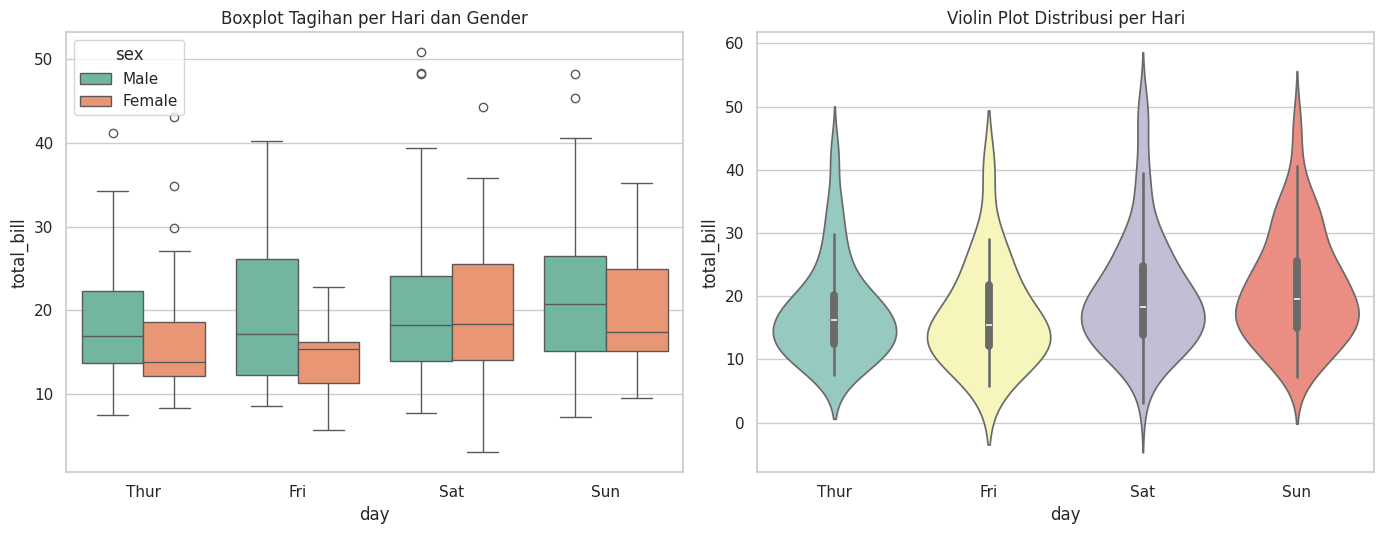

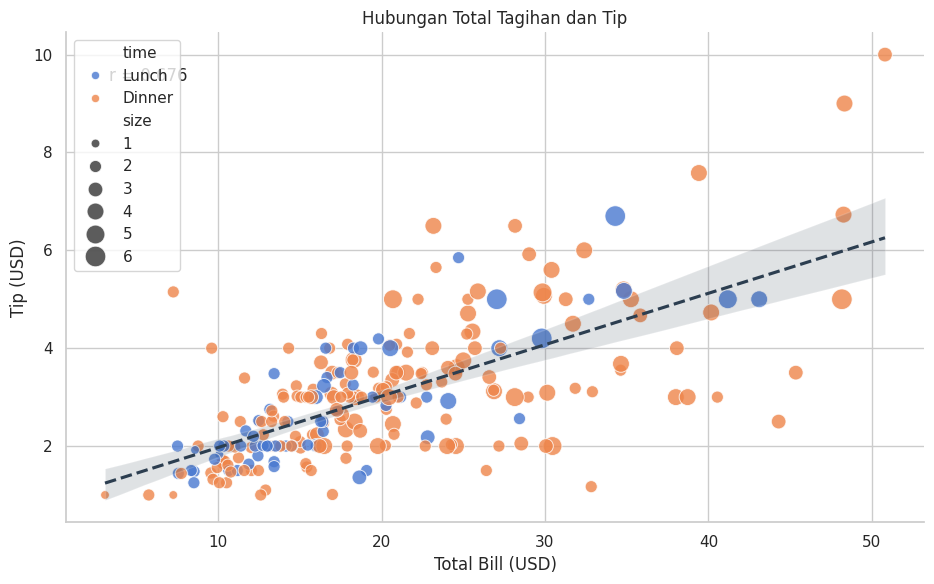

In [3]:
# Grafik 3: Boxplot & Violin
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.boxplot(data=df, x='day', y='total_bill', hue='sex',
            order=urutan_hari, palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot Tagihan per Hari dan Gender')

sns.violinplot(data=df, x='day', y='total_bill', order=urutan_hari,
               palette='Set3', ax=axes[1])
axes[1].set_title('Violin Plot Distribusi per Hari')
plt.tight_layout()
plt.savefig('grafik3_box_novika.png', dpi=200, bbox_inches='tight')
plt.show()

# Grafik 4: Scatter Plot
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time',
                size='size', sizes=(40, 220), alpha=0.8, ax=ax)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False,
            color='#2c3e50', line_kws={'linestyle':'--'}, ax=ax)

r, p = stats.pearsonr(df['total_bill'], df['tip'])
ax.text(0.05, 0.9, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

ax.set_title('Hubungan Total Tagihan dan Tip')
ax.set_xlabel('Total Bill (USD)')
ax.set_ylabel('Tip (USD)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('grafik4_scatter_novika.png', dpi=200, bbox_inches='tight')
plt.show()

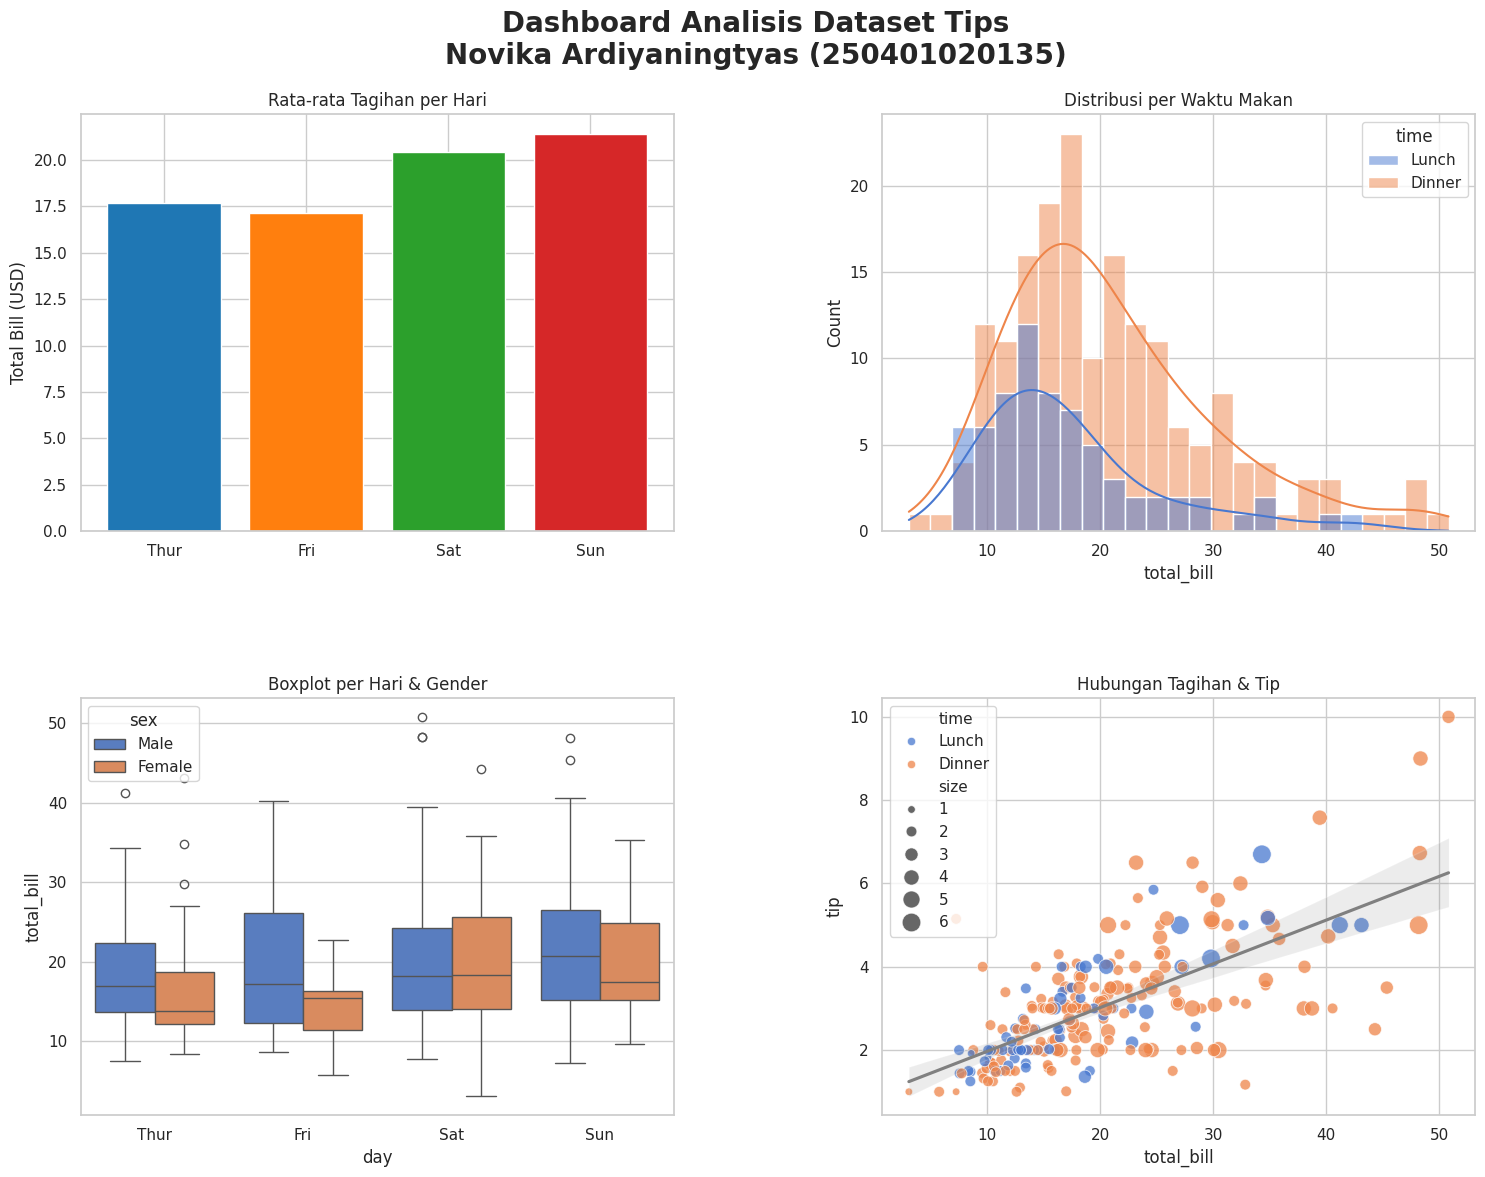

✅ Dashboard lengkap berhasil disimpan!


In [4]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Dashboard Analisis Dataset Tips\nNovika Ardiyaningtyas (250401020135)',
             fontsize=20, fontweight='bold', y=0.96)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1 di ax1
avg_bill = df.groupby('day', observed=True)['total_bill'].mean().reindex(urutan_hari)
ax1.bar(avg_bill.index, avg_bill.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='white')
ax1.set_title('Rata-rata Tagihan per Hari')
ax1.set_ylabel('Total Bill (USD)')

# Grafik 2 di ax2
sns.histplot(data=df, x='total_bill', hue='time', kde=True, bins=25, ax=ax2)
ax2.set_title('Distribusi per Waktu Makan')

# Grafik 3 di ax3
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', order=urutan_hari, ax=ax3)
ax3.set_title('Boxplot per Hari & Gender')

# Grafik 4 di ax4
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size',
                sizes=(30,180), alpha=0.75, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip')

plt.savefig('dashboard_tips_novika_final.png', dpi=200, bbox_inches='tight')
plt.show()
print('✅ Dashboard lengkap berhasil disimpan!')